<h1 align="center"> CSE 242 Assignment 5, Spring 2025

    Your name: Harshith Ravi kopparam          Student ID:2172472

## Instruction 

- Submit your assignments onto **canvas** by the due date. Upload a <code>zip</code> file containing:

    (1) The saved/latest <code>.ipynb</code> file, please **rename this file with your name included**.

    (2) Also save your file into a pdf version, if error appears, save an html version instead (easy to grade for written questions).
    
    **For assignment related questions, please reach TA or grader through Slack/Piazza/Email.**
    
- This is an **individual** assignment. All help from others (from the web, books other than text, or people other than the TA or instructor) must be clearly acknowledged. 

## Objective 

- **Task 1:** EM algorithm (Coding)
- **Task 2:** Neural Networks



# Question 1. (EM algorithm, 40 pts)

#### **Question 1.1.** Implement EM Algorithm in Python from scratch.


In [26]:
from scipy.stats import multivariate_normal 
import numpy as np


def e_step(data, mu, sigma, pi, k):

  ########################
  #### YOUR CODE HERE ####
  ########################
  n = data.shape[0]
  weights = np.zeros((n, k))
  # Creates a n*k matrix denoting probability of each point wrt each cluster 
  for i in range(k):
        # Add regularization to ensure positive definiteness
        cov = sigma[i] + np.eye(sigma[i].shape[0]) * 1e-6
        
        distribution = multivariate_normal(mean=mu[i], cov=cov, allow_singular=True)
        weights[:, i] = pi[i] * distribution.pdf(data)
    
  # Normalize AFTER computing all probabilities
  row_sums = np.sum(weights, axis=1, keepdims=True)
  row_sums = np.maximum(row_sums, 1e-10)  # Prevent division by zero
  weights = weights / row_sums
    

  return weights

def m_step(data, mu, sigma, pi, weights, k):

  ##################################################
  #### YOUR CODE HERE ##############################
  # HERE YOU WILL UPDATED VALUES OF mu, sigma and pi
  ##################################################
  n, d = data.shape
  mu_new = np.zeros((k, d))
  sigma_new = [np.zeros((d, d)) for _ in range(k)]
  pi_new = np.zeros(k)

  for i in range(k):
    weight = weights[:, i]
    total_weight = max(np.sum(weight), 1e-10)  # Prevent division by zero

  # Update parameters
    mu_new[i] = np.sum(data * weight[:, np.newaxis], axis=0) / total_weight
        
    diff = data - mu_new[i]
    sigma_new[i] = (weight[:, np.newaxis] * diff).T @ diff / total_weight
        
  # Add regularization for positive definiteness
    sigma_new[i] = sigma_new[i] + np.eye(d) * 1e-6
        
    pi_new[i] = total_weight / n
  
  return mu, sigma, pi      # updated mu, sigma, pi


def gmm(data, mu, sigma, pi, k, max_iterations=1000):    

    for j in range(max_iterations):
        # update cluter assignment weights
        weights = e_step(data, mu, sigma, pi, k)    # WRITE CODE FOR E-Step
        
        # update mu, sigma and prior proabilities locations
        mu, sigma, pi = m_step(data, mu, sigma, pi, weights, k)  # WRITE CODE FOR M-Step
        
    # final assignment update
    weights = e_step(data, mu, sigma, pi, k)
    assignments = np.argmax(weights, axis=1)      # pick cluster with maximum probability weight for cluster assignment

    return mu, sigma, pi, assignments

In [27]:
def test_gmm(n_samples=4000, n_clusters=4, random_state=0):
    """
    Test function for GMM implementation with improved numerical stability
    """
    # Set random seed
    np.random.seed(random_state)
    
    # Generate synthetic data
    X, true_labels = make_blobs(
        n_samples=n_samples,
        centers=n_clusters,
        cluster_std=0.60,
        random_state=random_state
    )
    
    # Initialize parameters
    pi_initial = np.full(n_clusters, 1/n_clusters)
    
    # Random initialization of means
    random_idx = np.random.choice(X.shape[0], size=n_clusters, replace=False)
    mu_initial = X[random_idx]
    
    # Initialize covariance matrices with identity matrix
    sigma_initial = [np.eye(X.shape[1]) for _ in range(n_clusters)]
    
    # Add regularization term to avoid singular matrices
    reg_cov = 1e-6 * np.eye(X.shape[1])
    sigma_initial = [s + reg_cov for s in sigma_initial]
    
    # Convert lists to numpy arrays
    mu_initial = np.array(mu_initial)
    sigma_initial = np.array(sigma_initial)
    
    # Run GMM
    try:
        mu, sigma, pi, assignments = gmm(X, mu_initial, sigma_initial, pi_initial, n_clusters)
        
        # Visualization
        colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]
        plt.figure(figsize=(12, 5))
        
        # Plot GMM results
        plt.subplot(121)
        plt.title(f"GMM Clustering Results (k={n_clusters})")
        
        # Plot data points with assignments
        for i in range(n_clusters):
            cluster_data = assignments == i
            plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                       c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
        
        # Plot ellipses
        for i in range(n_clusters):
            eigenvals, eigenvecs = np.linalg.eig(sigma[i])
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            ellip = Ellipse(mu[i], 2 * np.sqrt(eigenvals[0]), 
                           2 * np.sqrt(eigenvals[1]),
                           angle=angle, fill=False, color=colors[i])
            plt.gca().add_patch(ellip)
        
        plt.legend()
        
        # Plot true labels
        plt.subplot(122)
        plt.title("True Labels")
        for i in range(n_clusters):
            cluster_data = true_labels == i
            plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                       c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        return mu, sigma, pi, assignments
    
    except np.linalg.LinAlgError as e:
        print(f"Error encountered: {e}")
        print("Try increasing the regularization term or reinitializing the parameters")
        return None, None, None, None

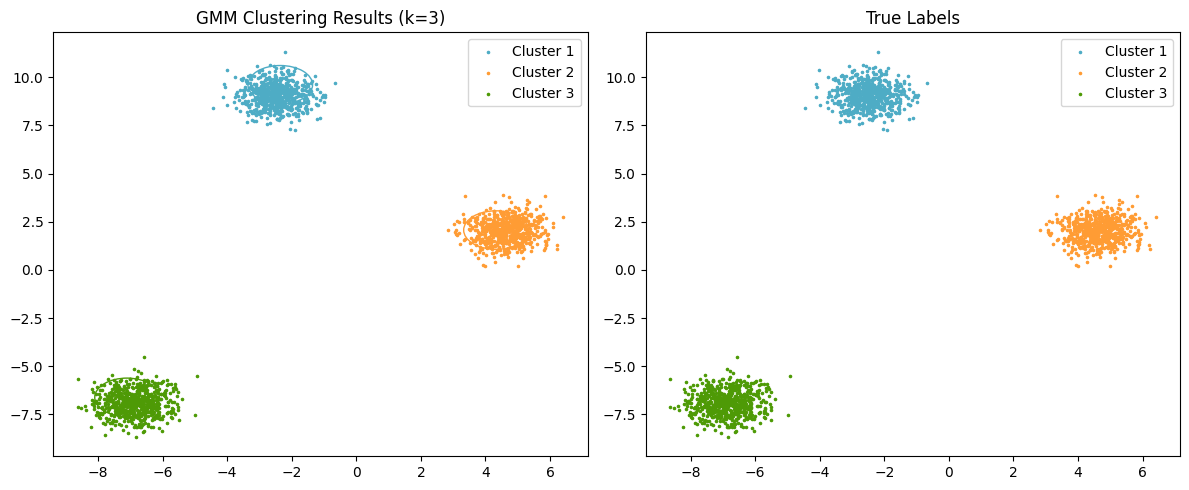

Final cluster centers (mu): [[-2.35557978  9.60390072]
 [ 4.3254258   2.06458261]
 [-7.10301862 -6.61772168]]
Final covariance matrices (sigma): [[[1.000001 0.      ]
  [0.       1.000001]]

 [[1.000001 0.      ]
  [0.       1.000001]]

 [[1.000001 0.      ]
  [0.       1.000001]]]


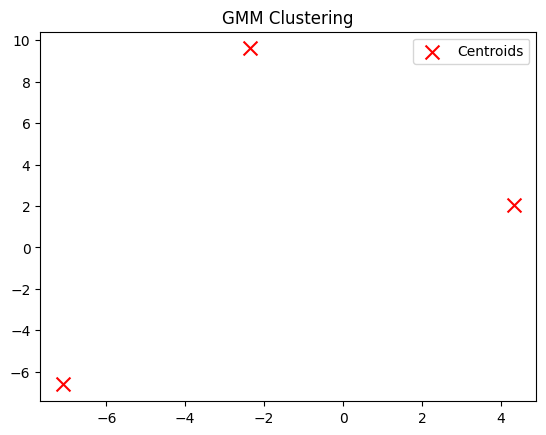

In [28]:
mu, sigma, pi, assignments = test_gmm(n_samples=2000, n_clusters=3, random_state=42)
if mu is not None:
    print("Final cluster centers (mu):", mu)
    print("Final covariance matrices (sigma):", sigma)
    plt.scatter(mu[:, 0], mu[:, 1], c="red", marker="x", s=100, label="Centroids")
    plt.legend()
    plt.title("GMM Clustering")
    plt.show()

#### **Question 1.2.** Run your code on following toy dataset similar to K-Means in the Assignment 4 for different k-values, where k = {3, 4} and 

1. visualize 2D gaussian ellipses with $\mu$ and $\Sigma$ you obtained.
2. plot the cluster assignments for different k's (as done in assignment 4) for both GMM and K-Means side by side for comparison. 
3. Write your observations (open question)

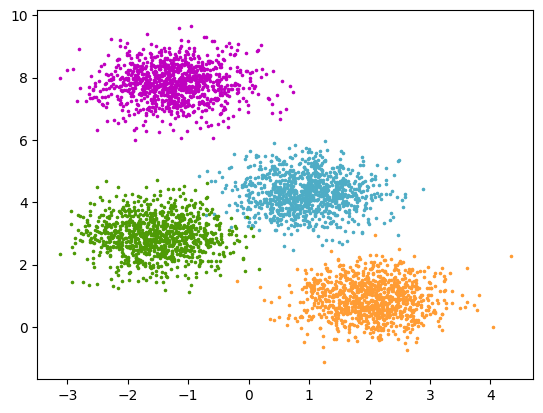

In [10]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate sample data
n_samples = 4000
n_components = 4

X, y_true = make_blobs(
    n_samples=n_samples, centers=n_components, cluster_std=0.60, random_state=0
)

colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]

for k, col in enumerate(colors):
    cluster_data = y_true == k
    plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=col, marker=".", s=10)


In [22]:
def test_gmm(n_samples=4000, n_clusters=4, random_state=0):
    """
    Test function for GMM implementation
    
    Parameters:
    -----------
    n_samples: int
        Number of samples to generate
    n_clusters: int
        Number of clusters to fit
    random_state: int
        Random seed for reproducibility
    """
    # Generate synthetic data
    X, true_labels = make_blobs(
        n_samples=n_samples,
        centers=n_clusters,
        cluster_std=0.60,
        random_state=random_state
    )
    
    # Initialize parameters
    pi_initial, z_ik_initial, mu_initial, sigma_initial = get_initial_parameters(n_clusters, X)
    mu_initial = np.array(mu_initial)
    sigma_initial = np.array(sigma_initial)
    
    # Add small regularization to avoid singular matrices
    sigma_initial = np.array([s + np.eye(X.shape[1]) * 1e-6 for s in sigma_initial])
    
    # Run GMM
    mu, sigma, pi, assignments = gmm(X, mu_initial, sigma_initial, pi_initial, n_clusters)
    
    # Visualization
    colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]
    plt.figure(figsize=(12, 5))
    
    # Plot GMM results
    plt.subplot(121)
    plt.title(f"GMM Clustering Results (k={n_clusters})")
    
    # Plot data points
    for i in range(n_clusters):
        cluster_data = assignments == i
        plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                   c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
    
    # Plot ellipses
    for i in range(n_clusters):
        eigenvals, eigenvecs = np.linalg.eig(sigma[i])
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        ellip = Ellipse(mu[i], 2 * np.sqrt(eigenvals[0]), 
                       2 * np.sqrt(eigenvals[1]),
                       angle=angle, fill=False, color=colors[i])
        plt.gca().add_patch(ellip)
    
    plt.legend()
    
    # Plot true labels
    plt.subplot(122)
    plt.title("True Labels")
    for i in range(n_clusters):
        cluster_data = true_labels == i
        plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                   c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return mu, sigma, pi, assignments

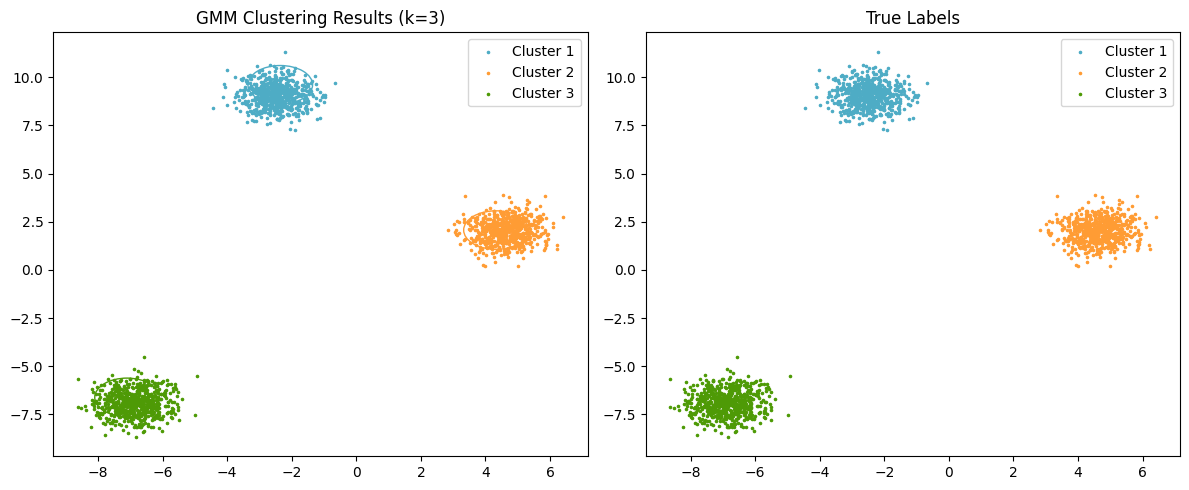

Final cluster centers (mu): [[-2.35557978  9.60390072]
 [ 4.3254258   2.06458261]
 [-7.10301862 -6.61772168]]
Final covariance matrices (sigma): [[[1.000001 0.      ]
  [0.       1.000001]]

 [[1.000001 0.      ]
  [0.       1.000001]]

 [[1.000001 0.      ]
  [0.       1.000001]]]


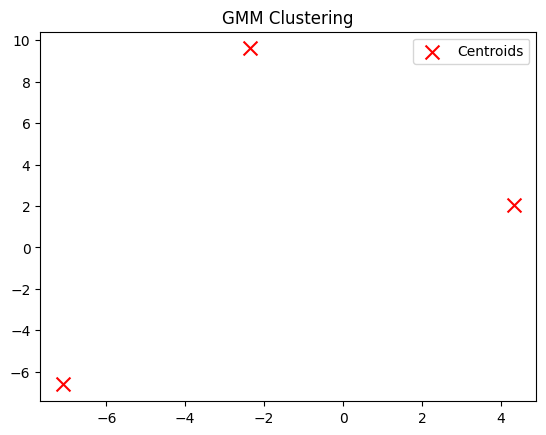

In [29]:
mu, sigma, pi, assignments = test_gmm(n_samples=2000, n_clusters=3, random_state=42)
print("Final cluster centers (mu):", mu)
print("Final covariance matrices (sigma):", sigma)
plt.scatter(mu[:, 0], mu[:, 1], c="red", marker="x", s=100, label="Centroids")
plt.legend()
plt.title("GMM Clustering")
plt.show()

In [30]:
def update_assignments(data, centroids):

  ########################
  #### YOUR CODE HERE ####

  ## you will get cluster# 
  ##assignments here #####
  ########################
  distances = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis=2))
  assignments=np.argmin(distances, axis=0)
  return assignments

def update_centroids(data, centroids, assignments):
    new_centroids = np.zeros_like(centroids)
    for k in range(len(centroids)):
        mask = assignments == k
        if np.any(mask):
            new_centroids[k] = data[mask].mean(axis=0)
        else:
            new_centroids[k] = centroids[k]
    return new_centroids  # Fix: Move return outside the loop


def kmeans(data, centroids, max_iterations):    

    for j in range(max_iterations):
        # update cluter assignments
        assignments = update_assignments(data,centroids)    # WRITE CODE FOR update_assignments
        
        # update centroid locations
        centroids = update_centroids(data,centroids,assignments)  # WRITE CODE FOR update_centroids
        
    # final assignment update
    assignments = update_assignments(data,centroids)
    return centroids, assignments

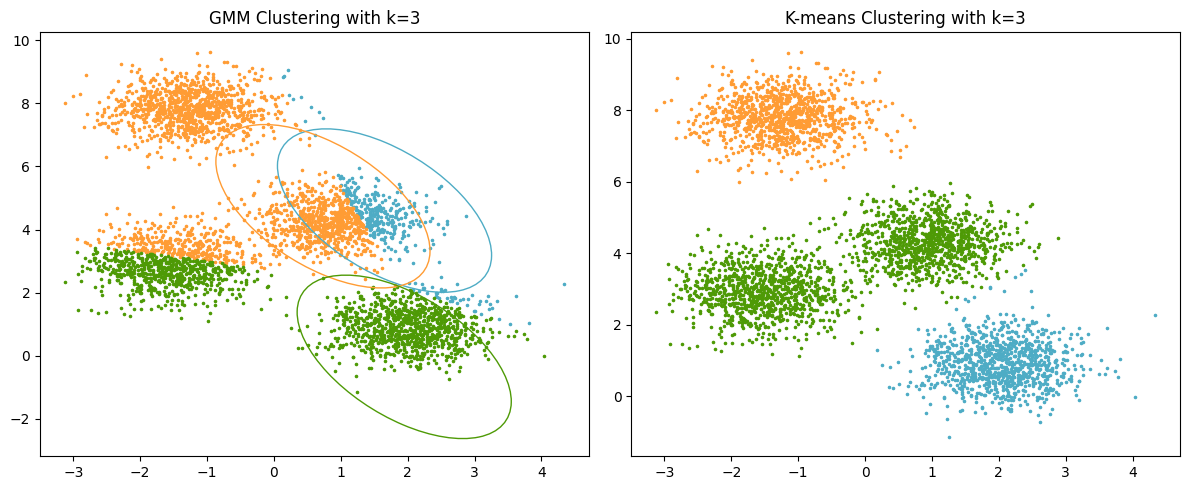

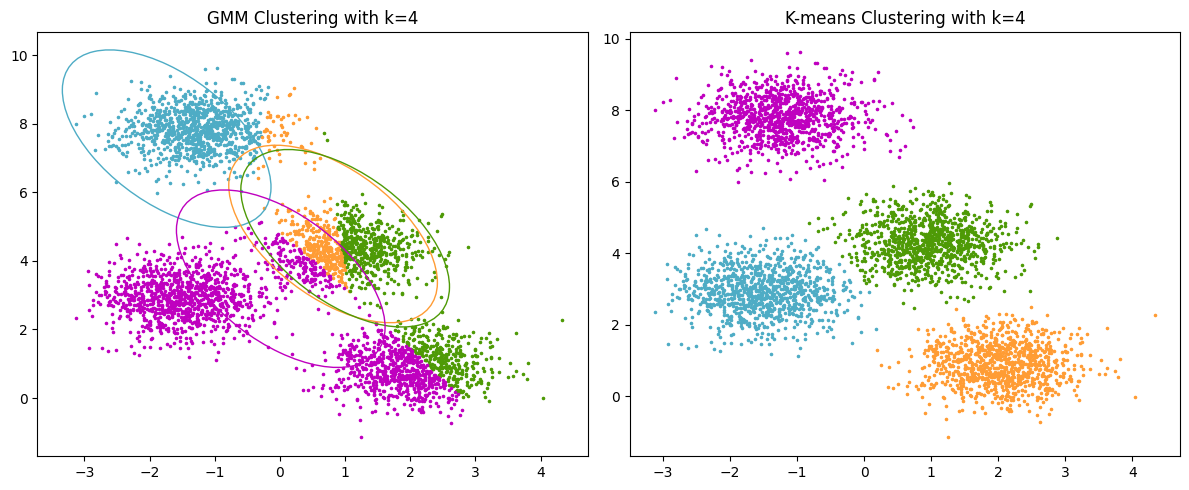

In [31]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches
from matplotlib.patches import Ellipse
# function to get initial cluster centroids; we randomly choose k points from the dataset 
def get_initial_parameters(k, X):

  # initial weights given to each cluster are stored in phi or P(Ci=j)
  pi = np.full(shape=k, fill_value=1/k) 

  # initial weights given to each data point wrt to each cluster or P(Xi/Ci=j)
  z_ik = np.full(shape=X.shape, fill_value=1/k)

  # dataset is divided randomly into k parts of unequal sizes
  random_row = np.random.randint(low=0, high=X.shape[0], size=k)

  # initial value of mean of k Gaussians
  mu = [  X[row_index,:] for row_index in random_row ] 

  # initial value of covariance matrix of k Gaussians
  sigma = [ np.cov(X.T) for _ in range(k) ] 
  
  return pi, z_ik, mu, sigma

# Main clustering loop
for n_clusters in [3, 4]:  # Changed k to n_clusters
    pi_initial, z_ik_initial, mu_initial, sigma_initial = get_initial_parameters(n_clusters, X)
    mu_initial = np.array(mu_initial)
    sigma_initial = np.array(sigma_initial)
    
    # Run GMM
    mu, sigma, pi, gmm_cluster_assignments = gmm(X, mu_initial, sigma_initial, pi_initial, n_clusters)
    
    # Plot GMM results with Gaussian ellipses
    plt.figure(figsize=(12, 5))
    plt.subplot(121)
    plt.title(f"GMM Clustering with k={n_clusters}")
    
    # Plot data points
    for i in range(n_clusters):
        cluster_data = gmm_cluster_assignments == i
        plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=colors[i], marker=".", s=10)
    
    # Plot Gaussian ellipses
    for i in range(n_clusters):
        eigenvals, eigenvecs = np.linalg.eig(sigma[i])
        angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
        ellip = matplotlib.patches.Ellipse(mu[i], 2 * np.sqrt(eigenvals[0]), 
                                         2 * np.sqrt(eigenvals[1]),
                                         angle=angle, fill=False, color=colors[i])
        plt.gca().add_patch(ellip)
    
    # Run and plot K-means
    plt.subplot(122)
    plt.title(f"K-means Clustering with k={n_clusters}")
    
    # Initialize centroids
    initial_centroids = X[np.random.choice(X.shape[0], n_clusters, replace=False)]
    centroids, kmeans_assignments = kmeans(X, initial_centroids, max_iterations=100)
    
    # Plot K-means results
    for i in range(n_clusters):
        cluster_data = kmeans_assignments == i
        plt.scatter(X[cluster_data, 0], X[cluster_data, 1], c=colors[i], marker=".", s=10)
    
    plt.tight_layout()
    plt.show()

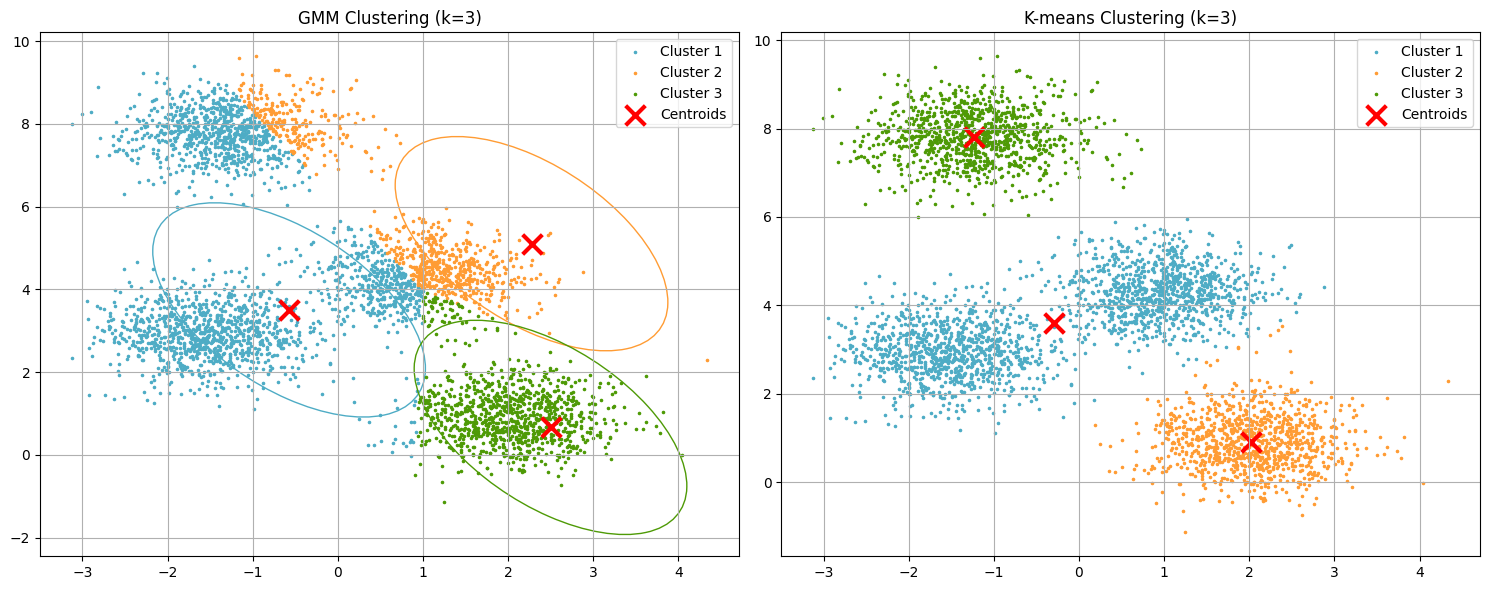

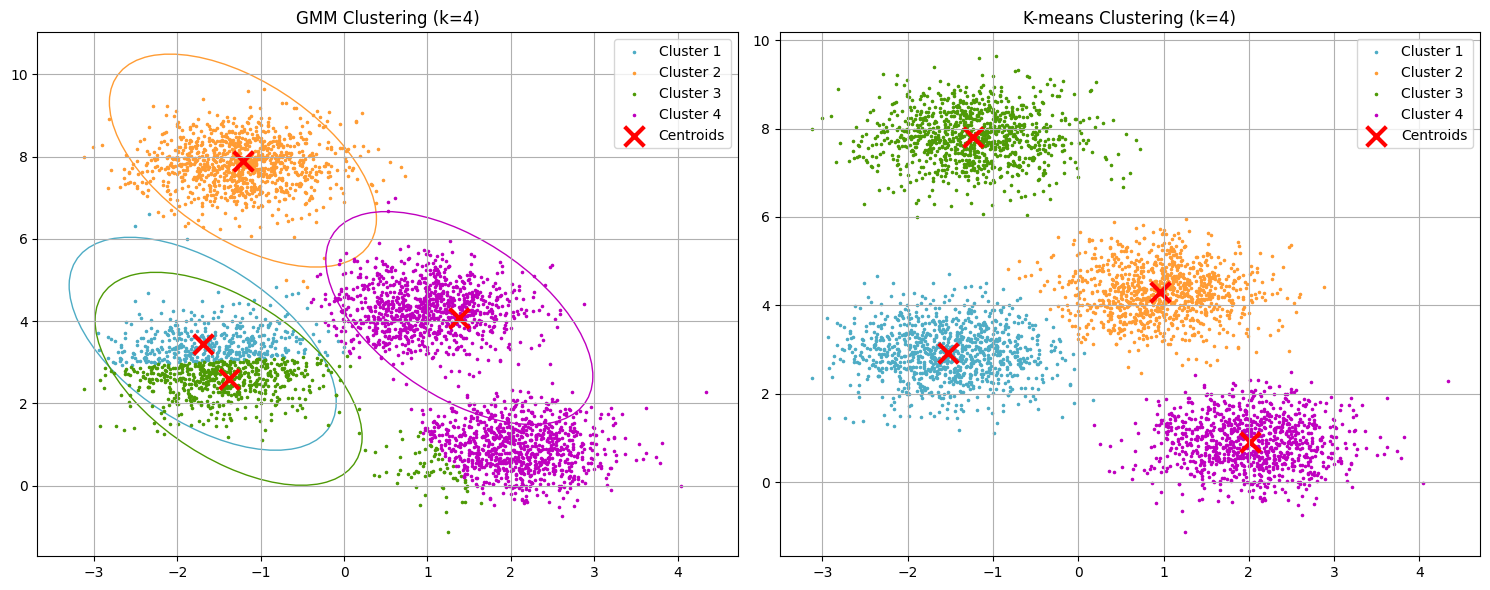

In [ ]:
# Main clustering loop with improved visualization
def compare_clustering(X, k_values=[3, 4], random_state=42):
    np.random.seed(random_state)
    colors = ["#4EACC5", "#FF9C34", "#4E9A06", "m"]
    
    for n_clusters in k_values:
        # Initialize GMM parameters
        pi_initial, z_ik_initial, mu_initial, sigma_initial = get_initial_parameters(n_clusters, X)
        mu_initial = np.array(mu_initial)
        sigma_initial = np.array(sigma_initial)
        
        # Run GMM
        mu, sigma, pi, gmm_assignments = gmm(X, mu_initial, sigma_initial, pi_initial, n_clusters)
        
        # Setup comparison plot
        plt.figure(figsize=(15, 6))
        
        # Plot GMM results
        plt.subplot(121)
        plt.title(f"GMM Clustering (k={n_clusters})")
        
        # Plot data points and GMM ellipses
        for i in range(n_clusters):
            cluster_data = gmm_assignments == i
            plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                       c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
            
            # Add Gaussian ellipses
            eigenvals, eigenvecs = np.linalg.eig(sigma[i])
            angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
            ellip = Ellipse(mu[i], 2 * np.sqrt(eigenvals[0]), 
                           2 * np.sqrt(eigenvals[1]),
                           angle=angle, fill=False, color=colors[i])
            plt.gca().add_patch(ellip)
        
        # Plot GMM centroids
        plt.scatter(mu[:, 0], mu[:, 1], c='red', marker='x', 
                   s=200, linewidths=3, label='Centroids')
        plt.legend()
        plt.grid(True)
        
        # Run and plot K-means
        plt.subplot(122)
        plt.title(f"K-means Clustering (k={n_clusters})")
        
        # Initialize and run K-means
        initial_centroids = X[np.random.choice(X.shape[0], n_clusters, replace=False)]
        centroids, kmeans_assignments = kmeans(X, initial_centroids, max_iterations=100)
        
        # Plot K-means results
        for i in range(n_clusters):
            cluster_data = kmeans_assignments == i
            plt.scatter(X[cluster_data, 0], X[cluster_data, 1], 
                       c=colors[i], marker=".", s=10, label=f'Cluster {i+1}')
        
        # Plot K-means centroids
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', 
                   s=200, linewidths=3, label='Centroids')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.show()

# Run the comparison
compare_clustering(X)

# Question 2. Neural Networks (60 pts)


Consider the following neural network:

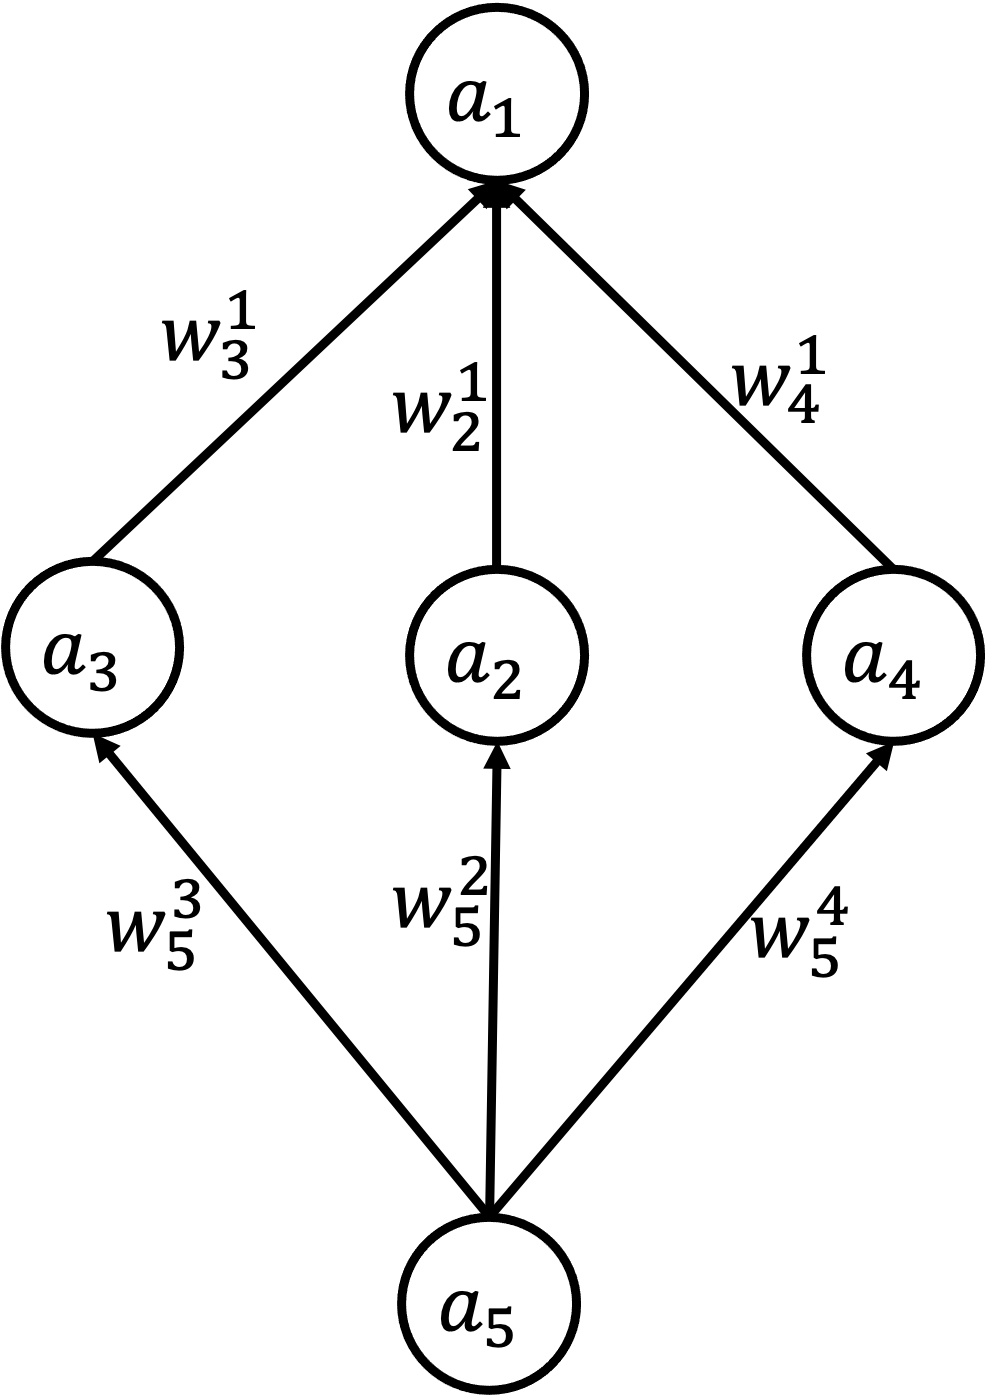

In [2]:

from IPython.display import Image

Image(filename='output.png', width=400) 

where $a_i = \Sigma_j w_j^i z_j$ , $z_i = f_i(a_i)$ for $i= 1, 2,3,4, z_5 = a_5$ (an input neuron), and $f_1(x) = f_2(x) = f_3(x) = f_4(x) = $ sigmoid$(x)$.


### **Question 2.1**. Write a function to simulate the neural network (10 pts) ###


**Answer:**

<!-- $$a_3 =$$
$$a_4 =$$
$$a_2 =$$

$$a_1 =$$

$$z_1 =$$ -->
$$
a_3 = a_5 \cdot w_{53}
$$

$$
a_4 = a_5 \cdot w_{54}
$$

$$
a_2 = a_5 \cdot w_{52}
$$

$$
a_1 = w_{31} \cdot \operatorname{sigmoid}(a_5 \cdot w_{53}) + w_{21} \cdot \operatorname{sigmoid}(a_5 \cdot w_{52}) + w_{41} \cdot \operatorname{sigmoid}(a_5 \cdot w_{54})
$$

$$
z_1 = \operatorname{sigmoid}\left(
    w_{31} \cdot \operatorname{sigmoid}(a_5 \cdot w_{53}) +
    w_{21} \cdot \operatorname{sigmoid}(a_5 \cdot w_{52}) +
    w_{41} \cdot \operatorname{sigmoid}(a_5 \cdot w_{54})
\right)
$$



### **Question 2.2** Deduce the equation to calculate $δ_i$ (the error value per neuron) for all the neurons. (20 pts) ###
Write a function that given a training sample and the weights of the network calculate $δ_i$ for each neuron.

**Hint:**
########################################

#### **SIGMOID** ####
$$f(x) = \dfrac{1}{1+e^{-x}} $$
$$df(x)/dx = f(x)(1-f(x))$$

########################################
#### **LOSS FUNCTION** ####
$$error = 0.5*(z_1 - target)^2$$
########################################

#### **DERIVATES** ####
$\partial{error}/\partial{w^1_3} = \partial error/\partial z_1* \partial z_1/\partial a_1 * \partial a_1/\partial w^1_3$ (using chain rule)

$δ_5 =  \partial error/\partial w^3_5 + \partial error/\partial w^2_5 + \partial error/\partial w^4_5$ (total error from connected neurons)


**Answer:**

$\partial{error}/\partial{w^1_3} =(z_1 - target) \cdot z_1(1 - z_1) \cdot a_3$

$\partial error/\partial z_1 =z_1 - target$

$\partial z_1/\partial a_1 =z_1 (1 - z_1)$

$\partial a_1/\partial w^1_3 = a_3$

$\partial{error}/\partial{w^1_3}   =(z_1 - target) \cdot z_1(1 - z_1) \cdot a_3$

########################################

$\partial{error}/\partial{w^1_4} =(z_1 - target) \cdot z_1(1 - z_1) \cdot a_4$


########################################

$\partial{error}/\partial{w^1_2} =(z_1 - target) \cdot z_1(1 - z_1) \cdot a_2$


########################################

$\partial derror/\partial w^3_5 =\delta_3 \cdot a_5$



########################################

$\partial derror/\partial w^4_5 = \delta_4 \cdot a_5$


########################################

$\partial derror/\partial w^2_5 = \delta_2 \cdot a_5$


########################################

$\delta_1 = (z_1 - target) \cdot z_1 (1 - z_1)$

$\delta_2 = \delta_1 \cdot w_{21} \cdot a_2 (1 - a_2)$

$\delta_3 = \delta_1 \cdot w_{31} \cdot a_3 (1 - a_3)$

$\delta_4 = \delta_1 \cdot w_{41} \cdot a_4 (1 - a_4)$

$\delta_5 = a_5 (1 - a_5) \cdot (\delta_3 \cdot w_{53} + \delta_2 \cdot w_{52} + \delta_4 \cdot w_{54})$



### **Question 2.3** (30 pts) ###

Implement a function to train the neural network using the stochastic gradient  descent. Use this function to train the network with the following training samples:

\begin{array}{ c c }
 x & y  \\ 
 -3.0 & 0.7312  \\  
 -2.0 & 0.7339   \\  
 -1.5 & 0.7438 \\  
 -1.0 & 0.7832 \\  
 -0.5 & 0.8903 \\  
 0.0 & 0.9820 \\  
 0.5 & 0.8114 \\  
 1.0 & 0.5937 \\  
 1.5 & 0.5219 \\  
 2.0 & 0.5049 \\  
 3.0 & 0.5002  
\end{array}

Plot the evolution of the error and the final predictions of the trained network. Write down the weights of the trained nettwork.

Error at epoch 0 is 0.01539
Error at epoch 100 is 0.00765
Error at epoch 200 is 0.00687
Error at epoch 300 is 0.00676
Error at epoch 400 is 0.00673
Error at epoch 500 is 0.00672
Error at epoch 600 is 0.00671
Error at epoch 700 is 0.00670
Error at epoch 800 is 0.00670
Error at epoch 900 is 0.00669


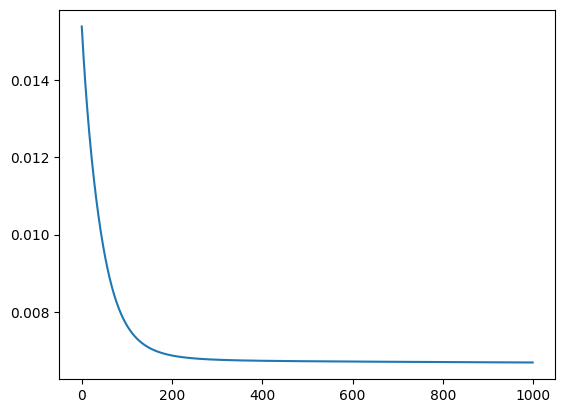

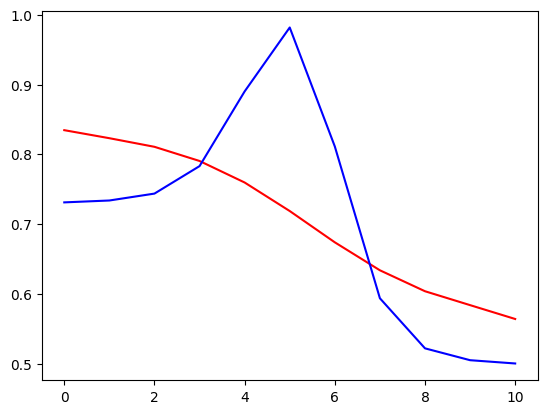

Weights of the network are: 
w13, w12, w14 [[-0.05729936  1.34284438  0.59150356]]
w35, w25, w45 [[ 0.6104735  -1.26193509 -0.04230599]]


In [7]:
##**Answer:**

import numpy as np 

# defining the backprop for Sigmoid Function
def back_sigmoid(x):
  # ### YOUR CODE HERE ###
  return sigmoid(x) * (1 - sigmoid(x))

# defining the Sigmoid Function
def sigmoid(x):
  # ### YOUR CODE HERE ###
  return 1 / (1 + np.exp(-x))

def forward_pass(X, weights_input_hidden, weights_hidden_output):

    # calculating hidden layer activations
    hiddenLayer_linearTransform = np.dot(X, weights_input_hidden)   # Nx1 * 1x3 = Nx3
    hiddenLayer_activations = sigmoid(hiddenLayer_linearTransform)  # Nx3

    # calculating the output
    outputLayer_linearTransform = np.dot(hiddenLayer_activations, weights_hidden_output)  # Nx3 * 3x1 = Nx1
    output = sigmoid(outputLayer_linearTransform)  # Nx1

    return output, hiddenLayer_activations


def backward_pass(X, y, output, weights_hidden_output, weights_input_hidden, hiddenLayer_activations):


  # calculating rate of change of error w.r.t weight between hidden and output layer

  error_wrt_output = output - y     # Nx1
  output_wrt_outputLayer_LinearTransform = back_sigmoid(output)      # Nx1

  outputLayer_LinearTransform_wrt_weights_hidden_output = hiddenLayer_activations   # Nx3

  # for w13, w12, w14
  error_wrt_weights_hidden_output = np.dot(outputLayer_LinearTransform_wrt_weights_hidden_output.T,
                                           error_wrt_output * output_wrt_outputLayer_LinearTransform)  # 1x3

  # calculating rate of change of error w.r.t weights between input and hidden layer
  outputLayer_LinearTransform_wrt_hiddenLayer_activations =  weights_hidden_output.T       # 1x3
  hiddenLayer_activations_wrt_hiddenLayer_linearTransform = back_sigmoid(hiddenLayer_activations) # Nx3

  hiddenLayer_linearTransform_wrt_weights_input_hidden =  X    # Nx1
  
  # for w35, w45, w25
  delta_hidden = (error_wrt_output * output_wrt_outputLayer_LinearTransform).dot(outputLayer_LinearTransform_wrt_hiddenLayer_activations) * hiddenLayer_activations_wrt_hiddenLayer_linearTransform  # Nx3
  error_wrt_weights_input_hidden = np.dot(hiddenLayer_linearTransform_wrt_weights_input_hidden.T, delta_hidden)   # 3x1


  return error_wrt_weights_hidden_output, error_wrt_weights_input_hidden


def train(X_train, y_train):

    # defining the model architecture
    inputLayer_neurons = 1  # number of neurons at input
    hiddenLayer_neurons = 3  # number of hidden layers neurons
    outputLayer_neurons = 1  # number of neurons at output layer

    # initializing weight
    weights_input_hidden = np.random.uniform(size=(inputLayer_neurons, hiddenLayer_neurons))
    weights_hidden_output = np.random.uniform(
        size=(hiddenLayer_neurons, outputLayer_neurons)
    )


    # defining the parameters
    lr = 0.1
    epochs = 1000

    losses =  []

    for ep in range(epochs):

      output_, hiddenLayer_activations = forward_pass(X_train, weights_input_hidden, weights_hidden_output)

      ## Backward Propagation
      # calculating error
      error = np.square(y_train - output_) / 2

      error_wrt_weights_hidden_output, error_wrt_weights_input_hidden = backward_pass(X_train, y_train, 
                                                                                      output_, 
                                                                                      weights_hidden_output, 
                                                                                      weights_input_hidden, 
                                                                                      hiddenLayer_activations)

      # updating the weights
      weights_hidden_output = weights_hidden_output - lr * error_wrt_weights_hidden_output
      weights_input_hidden = weights_input_hidden - lr * error_wrt_weights_input_hidden

      # print error at every 100th epoch
      epoch_loss = np.average(error)
      if ep % 100 == 0:
          print(f"Error at epoch {ep} is {epoch_loss:.5f}")

      # appending the error of each epoch
      losses.append(epoch_loss)

    import matplotlib.pyplot as plt
    plt.plot(losses)
    plt.show()

    final_pred, _ = forward_pass(X_train, weights_input_hidden, weights_hidden_output)

    plt.plot(final_pred, c='r')
    plt.plot(y_train, c='b')
    plt.show()

    print("Weights of the network are: ")
    print("w13, w12, w14", weights_hidden_output.T)
    print("w35, w25, w45", weights_input_hidden)

    


# defining training data
X_train = np.zeros((11, 1)).astype(np.float32)
y_train = np.zeros((11, 1)).astype(np.float32)

X_train[0] = -3
X_train[1] = -2
X_train[2] = -1.5
X_train[3] = -1.0
X_train[4] = -0.5
X_train[5] = 0.0
X_train[6] = 0.5
X_train[7] = 1.0
X_train[8] = 1.5
X_train[9] = 2.0
X_train[10] = 3.0


y_train[0] = 0.7312
y_train[1] = 0.7339
y_train[2] = 0.7438
y_train[3] = 0.7832
y_train[4] = 0.8903
y_train[5] = 0.9820
y_train[6] = 0.8114
y_train[7] = 0.5937
y_train[8] = 0.5219
y_train[9] = 0.5049
y_train[10] = 0.5002


train(X_train, y_train)